# CIFAR-10 CNN

In [1]:
import os
import numpy as np
import pandas as pd
from plt_rcs import *
import torch

In [2]:
plt.rc(group='figure', figsize=(4, 4))

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
device

device(type='mps')

In [4]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/dl'

In [5]:
os.chdir('../../data')

In [6]:
[i for i in os.listdir() if i.endswith('.pkl')]

['Diabetes.pkl',
 'Facility_Sensor_Raw.pkl',
 'Used_Cars_Prep.pkl',
 'Facility_Sensor_Out.pkl',
 'Used_Cars.pkl',
 'Encar_Merged_Prep_20220711.pkl',
 'WhiteWine.pkl',
 'Cereal.pkl',
 'Bank_Customer.pkl',
 'Marine_Product.pkl',
 'MNIST_Dataset.pkl',
 'APT_Price.pkl',
 'CIFAR10_Dataset.pkl']

In [7]:
objs = pd.read_pickle('CIFAR10_Dataset.pkl')

In [8]:
globals().update(objs)

In [9]:
%whos

Variable        Type       Data/Info
------------------------------------
device          device     mps
np              module     <module 'numpy' from '/op<...>kages/numpy/__init__.py'>
objs            dict       n=2
os              module     <module 'os' (frozen)>
pd              module     <module 'pandas' from '/o<...>ages/pandas/__init__.py'>
plt             module     <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
sns             module     <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
test_cifar10    CIFAR10    Dataset CIFAR10\n    Numb<...>5, 0.2616])\n           )
torch           module     <module 'torch' from '/op<...>kages/torch/__init__.py'>
train_cifar10   CIFAR10    Dataset CIFAR10\n    Numb<...>5, 0.2616])\n           )


In [10]:
test_cifar10, train_cifar10 = test_cifar10, train_cifar10

In [11]:
os.chdir('../code/dl')

In [12]:
from trainer import Trainer, set_seed

In [13]:
set_seed(seed=0)

In [14]:
from torch.utils.data import DataLoader

In [15]:
bs = 256

In [16]:
train_loader = DataLoader(dataset=train_cifar10, batch_size=bs, shuffle=True)
test_loader = DataLoader(dataset=test_cifar10, batch_size=bs, shuffle=False)

## 합성곱 신경망 모델 생성

In [17]:
import torch.nn as nn

In [18]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=32*16*16, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

In [19]:
sum([p.numel() for p in model.parameters() if p.requires_grad == True])
# 2110122

2110122

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [21]:
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader,
    flatten=False
)

[Trainer] Using device: mps:0


In [22]:
history = trainer.fit(n_epochs=10)
# [Epoch 01] Loss = 1.3798, Train_Acc = 0.6310, Test_Acc = 0.6044
# [Epoch 02] Loss = 0.9908, Train_Acc = 0.7073, Test_Acc = 0.6569
# [Epoch 03] Loss = 0.8103, Train_Acc = 0.7632, Test_Acc = 0.6753
# [Epoch 04] Loss = 0.6700, Train_Acc = 0.8267, Test_Acc = 0.6915
# [Epoch 05] Loss = 0.5351, Train_Acc = 0.8687, Test_Acc = 0.6892
# [Epoch 06] Loss = 0.4020, Train_Acc = 0.9141, Test_Acc = 0.6927
# [Epoch 07] Loss = 0.2884, Train_Acc = 0.9558, Test_Acc = 0.6954
# [Epoch 08] Loss = 0.1782, Train_Acc = 0.9720, Test_Acc = 0.6930
# [Epoch 09] Loss = 0.1120, Train_Acc = 0.9853, Test_Acc = 0.6919
# [Epoch 10] Loss = 0.0605, Train_Acc = 0.9878, Test_Acc = 0.6899

[Epoch 01] Loss = 1.3798, Train_Acc = 0.6310, Test_Acc = 0.6044
[Epoch 02] Loss = 0.9908, Train_Acc = 0.7073, Test_Acc = 0.6569
[Epoch 03] Loss = 0.8103, Train_Acc = 0.7632, Test_Acc = 0.6753
[Epoch 04] Loss = 0.6700, Train_Acc = 0.8267, Test_Acc = 0.6915
[Epoch 05] Loss = 0.5351, Train_Acc = 0.8687, Test_Acc = 0.6892
[Epoch 06] Loss = 0.4020, Train_Acc = 0.9141, Test_Acc = 0.6927
[Epoch 07] Loss = 0.2884, Train_Acc = 0.9558, Test_Acc = 0.6954
[Epoch 08] Loss = 0.1782, Train_Acc = 0.9720, Test_Acc = 0.6930
[Epoch 09] Loss = 0.1120, Train_Acc = 0.9853, Test_Acc = 0.6919
[Epoch 10] Loss = 0.0605, Train_Acc = 0.9878, Test_Acc = 0.6899
Total training time: 0 min 52 sec


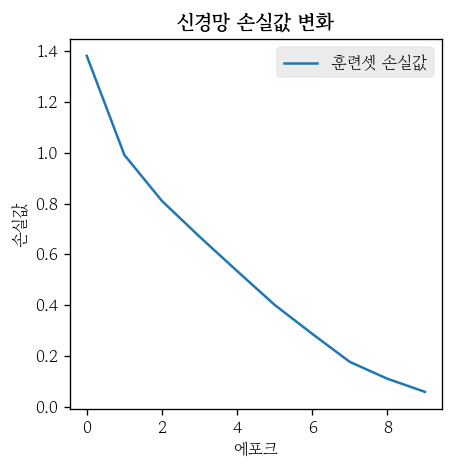

In [23]:
trainer.plot_loss()

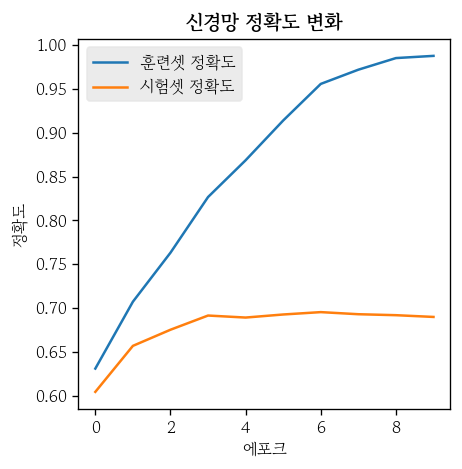

In [25]:
trainer.plot_accuracy()

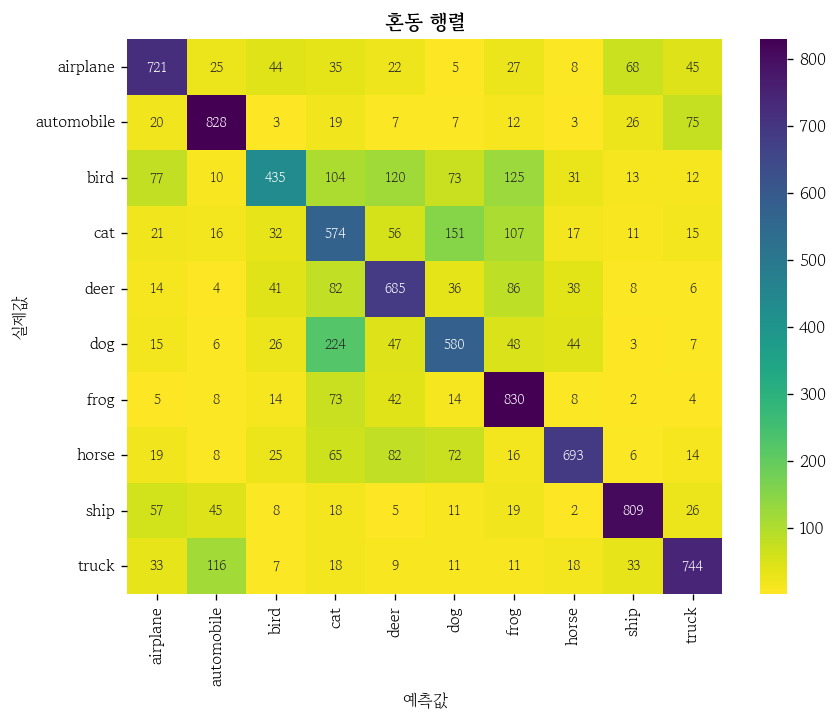

In [26]:
trainer.plot_confusion_matrix(data_loader=test_loader)

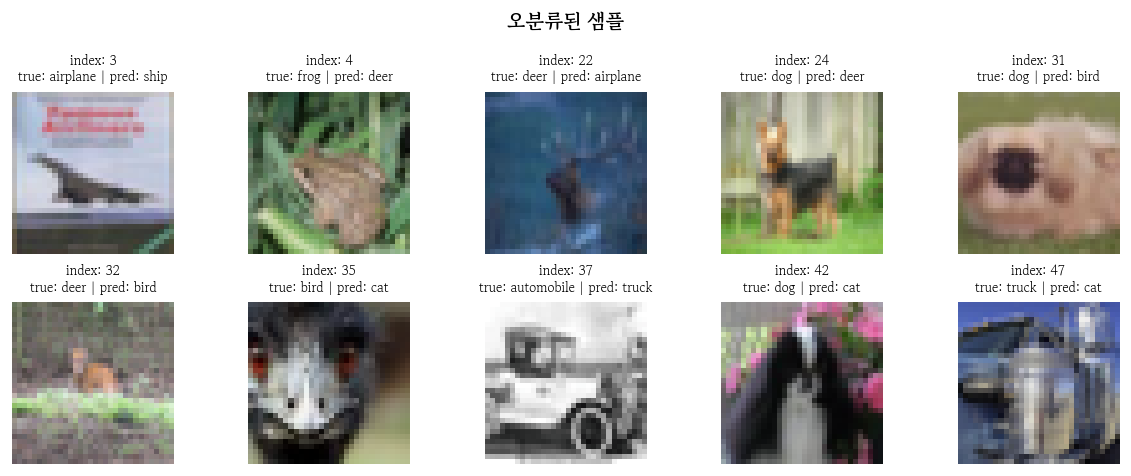

In [28]:
trainer.plot_misclassified(data_loader=test_loader, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616])

In [29]:
y_prob, y_pred, y_true = trainer.predict_loader(data_loader=test_loader)

In [30]:
mis_index = torch.where(y_true.ne(y_pred))[0]

In [31]:
mis_index[:10]

tensor([ 3,  4, 22, 24, 31, 32, 35, 37, 42, 47])

In [32]:
from gradcamviz import GradCAMViz

In [33]:
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Flatten(start_dim=1, end_dim=-1)
  (6): Linear(in_features=8192, out_features=256, bias=True)
  (7): ReLU()
  (8): Linear(in_features=256, out_features=10, bias=True)
)

In [34]:
target_layer = model[2]

In [35]:
viewer = GradCAMViz(model=model, target_layer=target_layer, data_loader=test_loader)

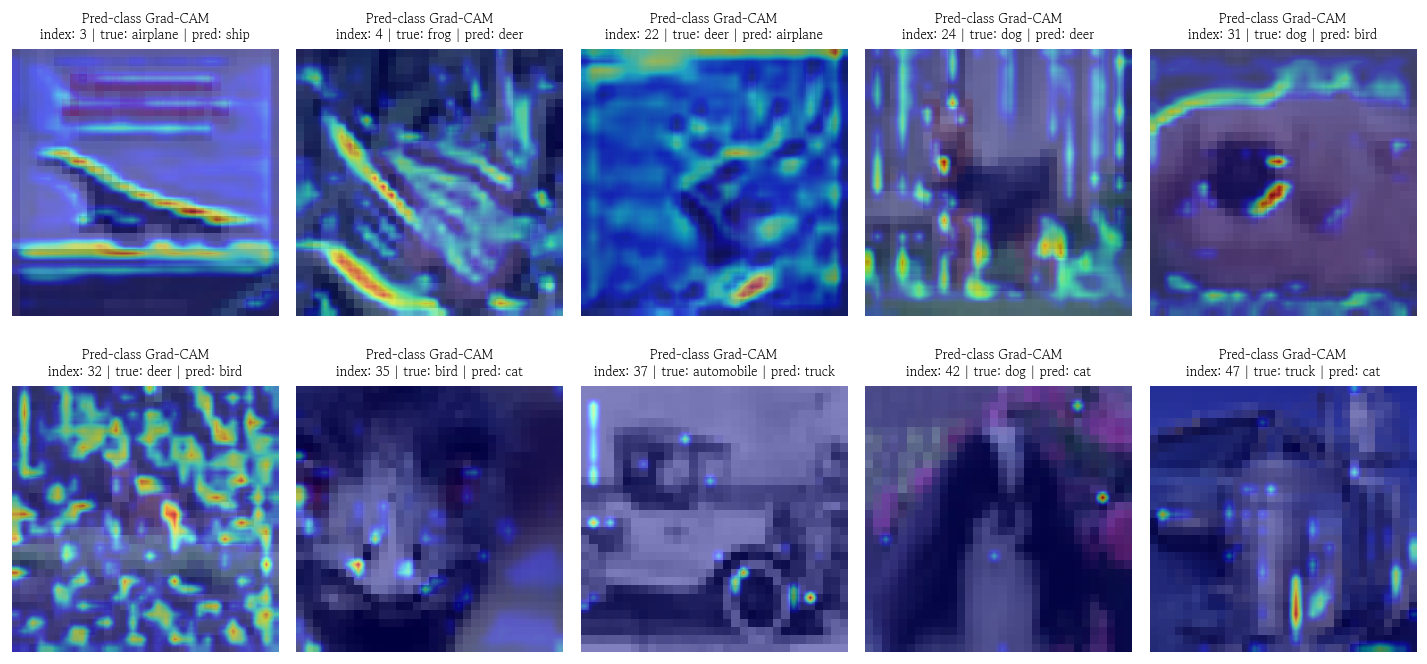

In [44]:
viewer.plot_multiple_samples(indices=mis_index[:10], nrows=2, ncols=5, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

In [39]:
idx = 25

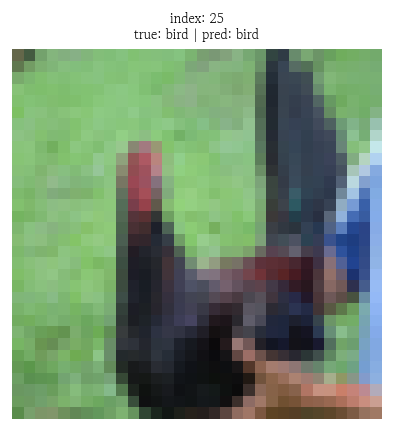

In [45]:
viewer.plot_original_image(index=idx, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

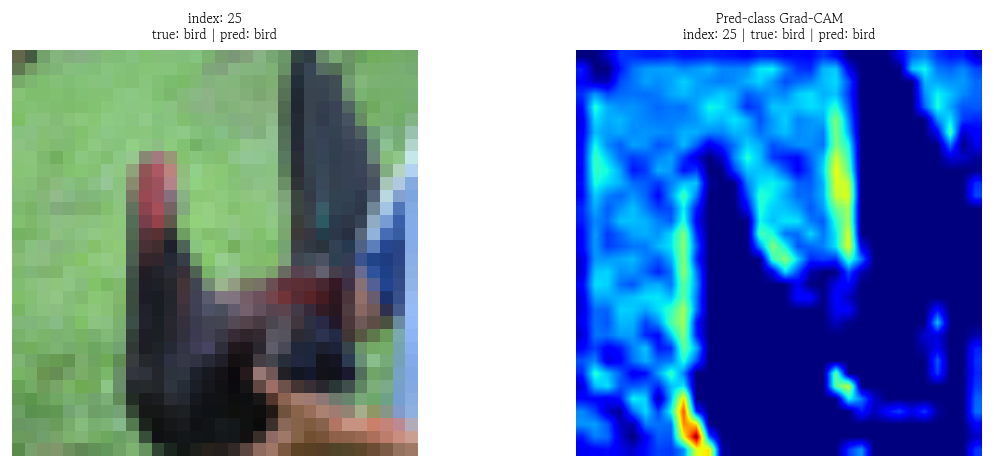

In [50]:
viewer.plot_sample(index=idx, overlay=False, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

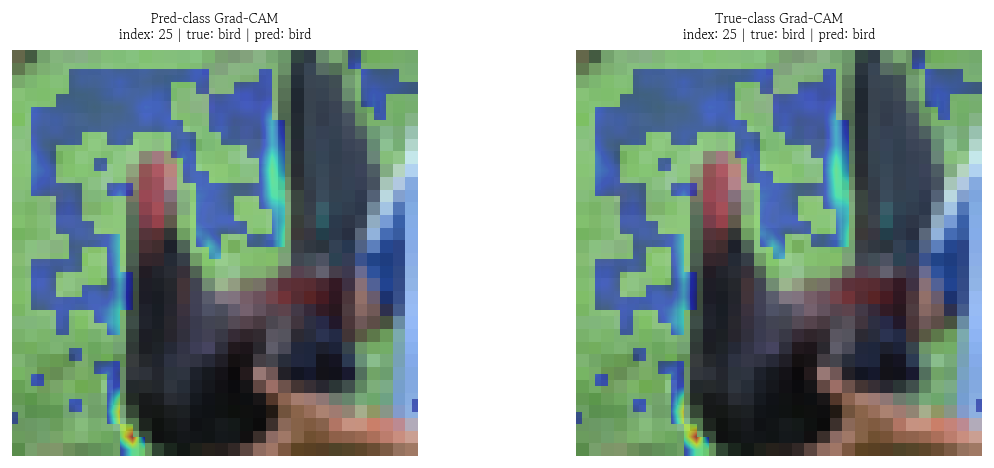

In [ ]:
viewer.plot_pred_true_comparison(
    index=idx, 
    mean=[0.4914, 0.4822, 0.4466], 
    std=[0.2470, 0.2435, 0.2616], 
    style='enhanced', # 생략 시 'simple'
    gamma=1.5, # gamma를 줄이면 히트맵 영역이 넓어짐
    cam_threshold=0.1 # cam_threshold를 줄이면 히트맵 영역이 넓어짐
);

## 배치 정규화 추가

In [56]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=32*16*16, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=10),
).to(device)

In [57]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [58]:
trainer.model = model
trainer.optimizer = optimizer

In [59]:
history = trainer.fit(n_epochs=10)

[Epoch 01] Loss = 1.4755, Train_Acc = 0.5957, Test_Acc = 0.5819
[Epoch 02] Loss = 1.0222, Train_Acc = 0.6952, Test_Acc = 0.6591
[Epoch 03] Loss = 0.8559, Train_Acc = 0.7195, Test_Acc = 0.6624
[Epoch 04] Loss = 0.7544, Train_Acc = 0.7485, Test_Acc = 0.6701
[Epoch 05] Loss = 0.6742, Train_Acc = 0.8035, Test_Acc = 0.6930
[Epoch 06] Loss = 0.5914, Train_Acc = 0.8402, Test_Acc = 0.7005
[Epoch 07] Loss = 0.5282, Train_Acc = 0.8388, Test_Acc = 0.6872
[Epoch 08] Loss = 0.4538, Train_Acc = 0.8669, Test_Acc = 0.6908
[Epoch 09] Loss = 0.3929, Train_Acc = 0.9025, Test_Acc = 0.6943
[Epoch 10] Loss = 0.3240, Train_Acc = 0.9234, Test_Acc = 0.6995
Total training time: 0 min 59 sec


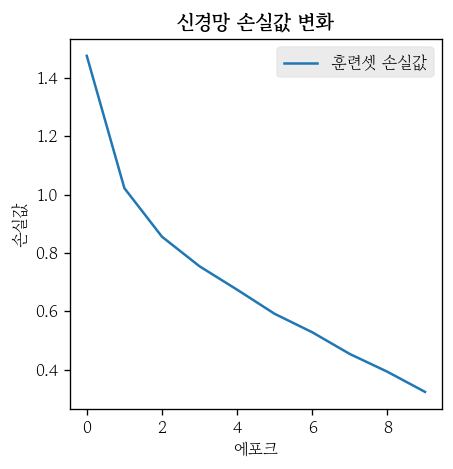

In [60]:
trainer.plot_loss()

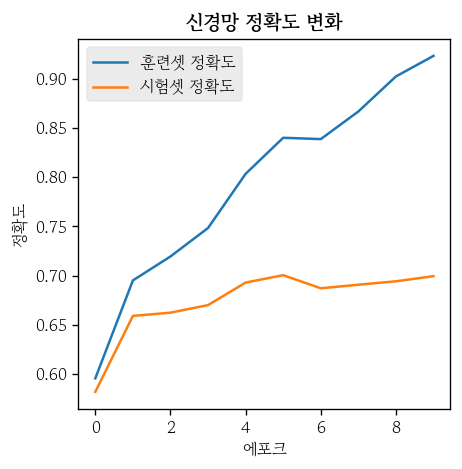

In [61]:
trainer.plot_accuracy()

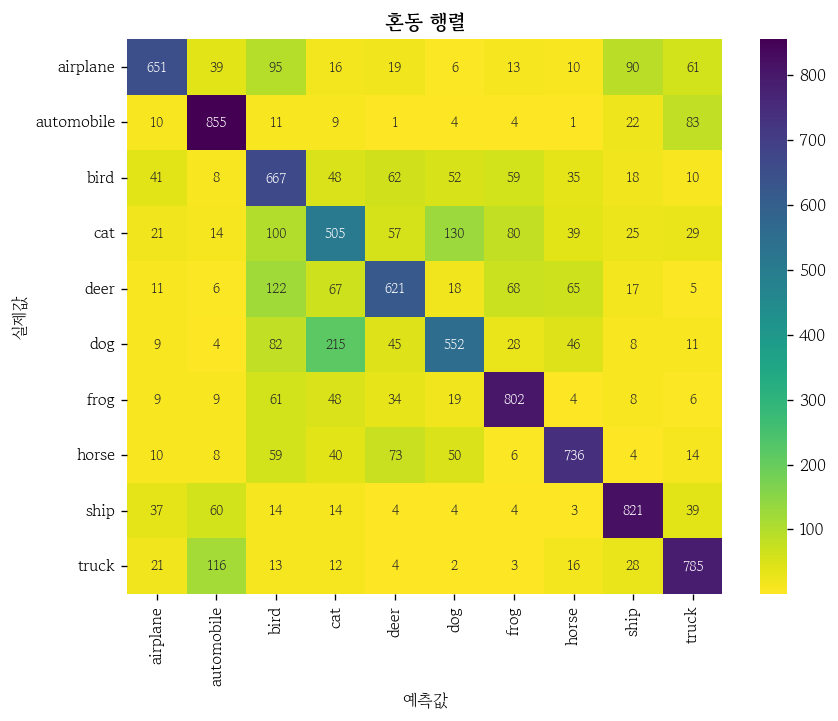

In [62]:
trainer.plot_confusion_matrix(data_loader=test_loader)

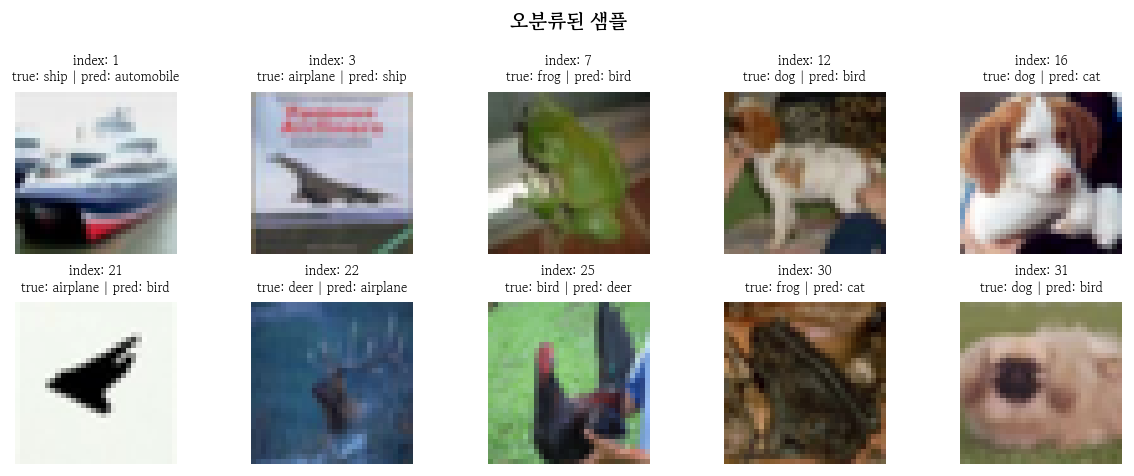

In [64]:
trainer.plot_misclassified(data_loader=test_loader, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616])

In [65]:
y_prob, y_pred, y_true = trainer.predict_loader(test_loader)

In [66]:
mis_index = torch.where(y_true.ne(y_pred))[0]

In [67]:
mis_index[:10]

tensor([ 1,  3,  7, 12, 16, 21, 22, 25, 30, 31])

In [68]:
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=8192, out_features=256, bias=True)
  (9): ReLU()
  (10): Linear(in_features=256, out_features=10, bias=True)
)

In [69]:
target_layer = model[3]

In [70]:
viewer = GradCAMViz(model=model, target_layer=target_layer, data_loader=test_loader)

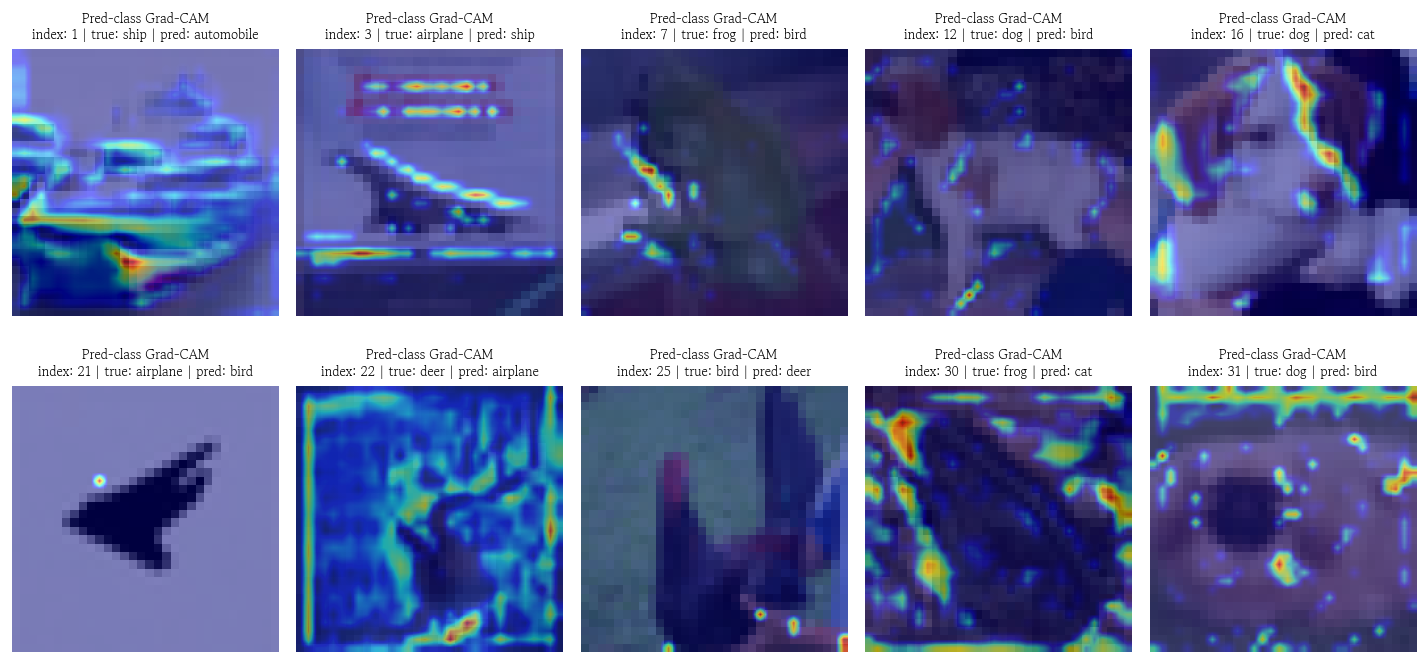

In [72]:
viewer.plot_multiple_samples(indices=mis_index[:10], nrows=2, ncols=5, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

In [73]:
index = 37

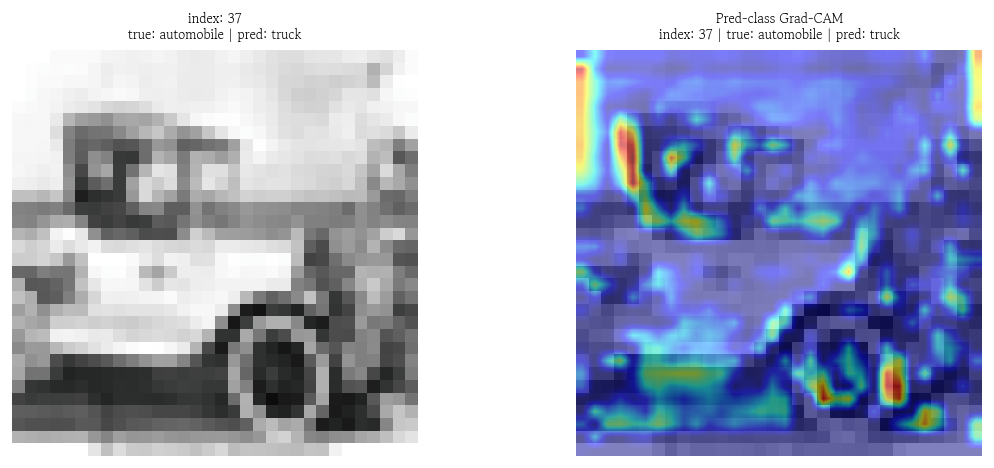

In [75]:
viewer.plot_sample(index=index, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

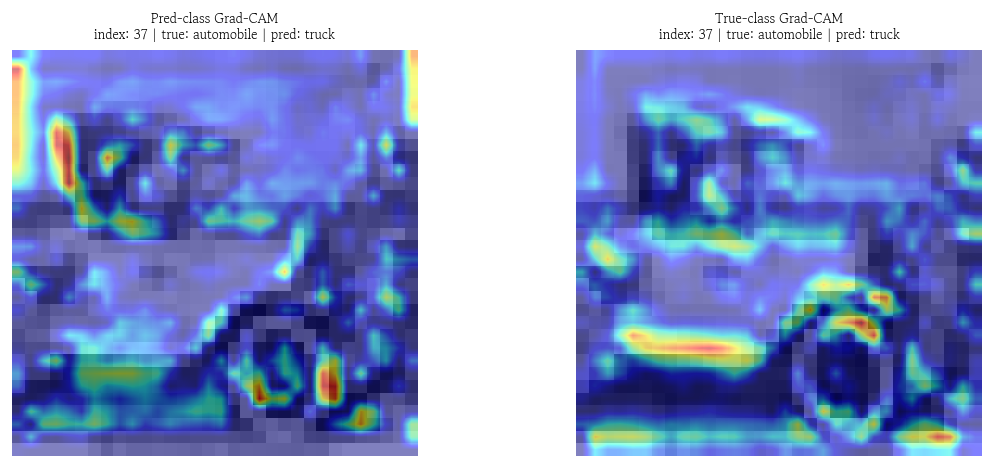

In [76]:
viewer.plot_pred_true_comparison(index=index, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

## 드롭아웃 추가

In [77]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=32*16*16, out_features=256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features=256, out_features=10),
).to(device)

In [78]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [79]:
trainer.model = model
trainer.optimizer = optimizer

In [80]:
history = trainer.fit(n_epochs=10)

[Epoch 01] Loss = 1.6936, Train_Acc = 0.5430, Test_Acc = 0.5297
[Epoch 02] Loss = 1.2573, Train_Acc = 0.6320, Test_Acc = 0.6083
[Epoch 03] Loss = 1.1015, Train_Acc = 0.6919, Test_Acc = 0.6536
[Epoch 04] Loss = 1.0074, Train_Acc = 0.6989, Test_Acc = 0.6465
[Epoch 05] Loss = 0.9349, Train_Acc = 0.7394, Test_Acc = 0.6793
[Epoch 06] Loss = 0.8883, Train_Acc = 0.7551, Test_Acc = 0.6841
[Epoch 07] Loss = 0.8400, Train_Acc = 0.7760, Test_Acc = 0.6900
[Epoch 08] Loss = 0.7936, Train_Acc = 0.7912, Test_Acc = 0.6885
[Epoch 09] Loss = 0.7675, Train_Acc = 0.7998, Test_Acc = 0.6940
[Epoch 10] Loss = 0.7360, Train_Acc = 0.8129, Test_Acc = 0.6959
Total training time: 0 min 58 sec


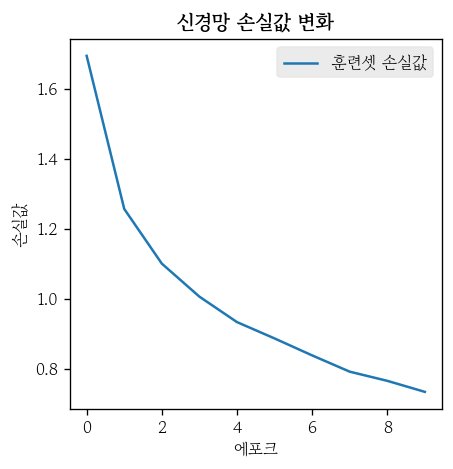

In [81]:
trainer.plot_loss()

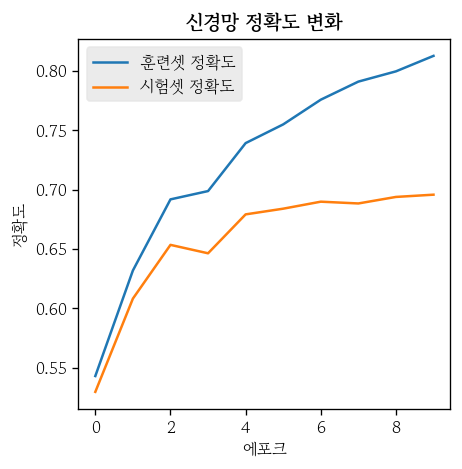

In [82]:
trainer.plot_accuracy()

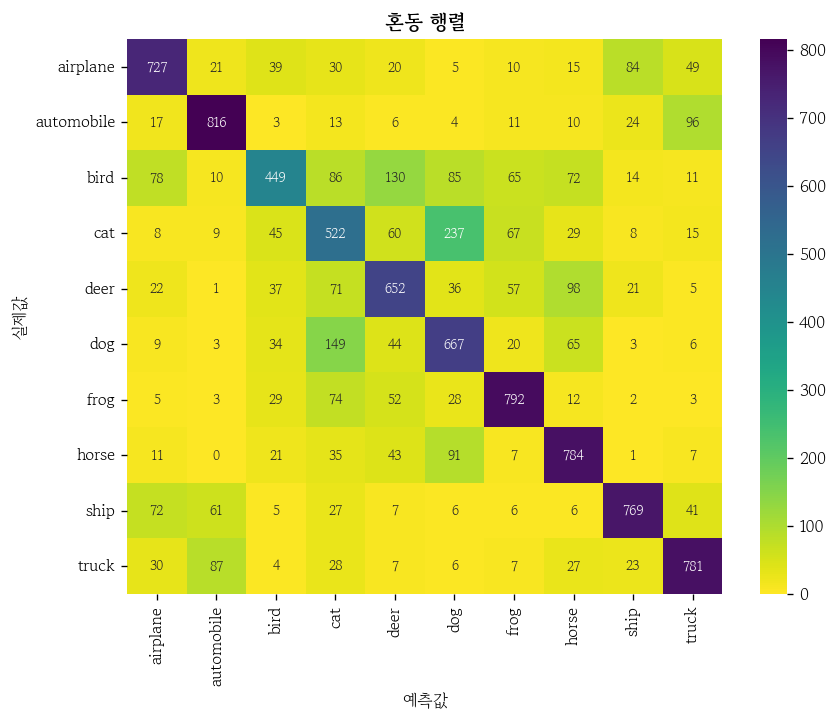

In [83]:
trainer.plot_confusion_matrix(data_loader=test_loader)

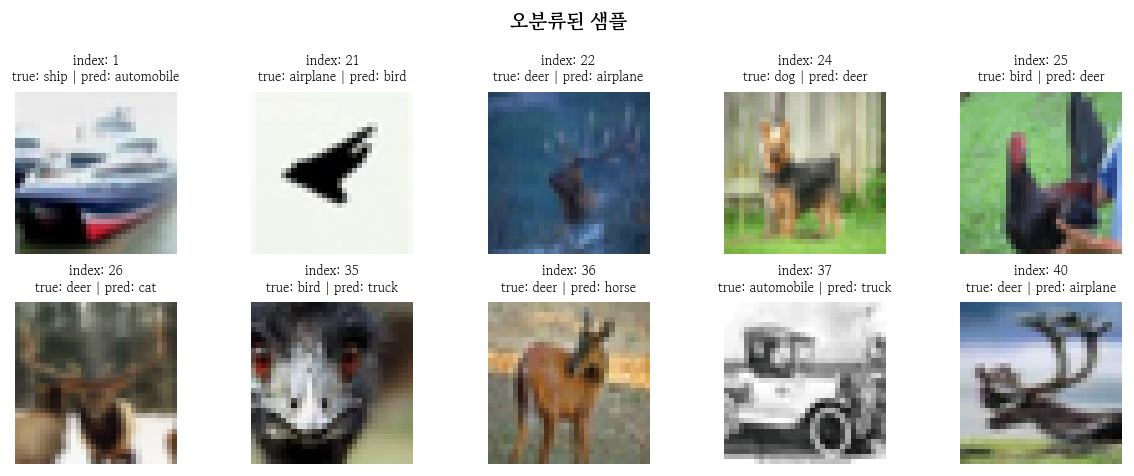

In [84]:
trainer.plot_misclassified(data_loader=test_loader, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

In [85]:
y_prob, y_pred, y_true = trainer.predict_loader(test_loader)

In [86]:
mis_index = torch.where(y_true.ne(y_pred))[0]

In [87]:
mis_index[:10]

tensor([ 1, 21, 22, 24, 25, 26, 35, 36, 37, 40])

In [88]:
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=8192, out_features=256, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.3, inplace=False)
  (11): Linear(in_features=256, out_features=10, bias=True)
)

In [89]:
target_layer = model[3]

In [90]:
viewer = GradCAMViz(model=model, target_layer=target_layer, data_loader=test_loader)

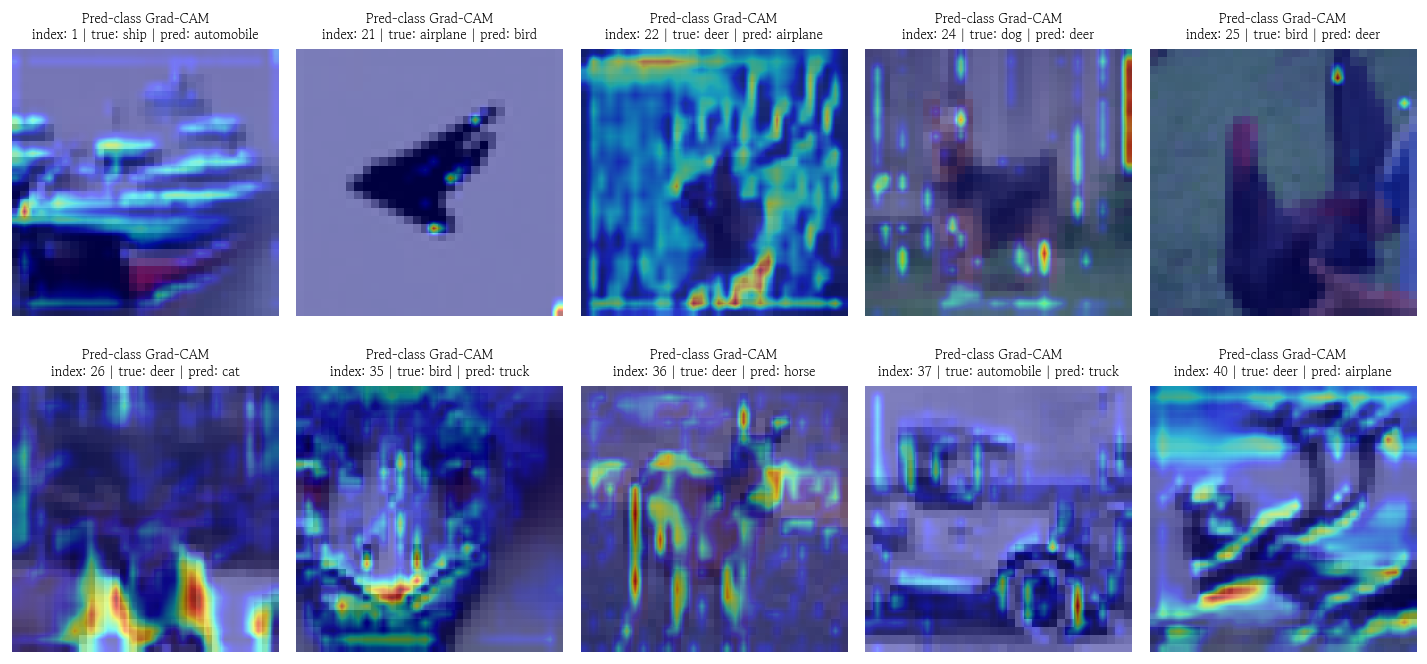

In [91]:
viewer.plot_multiple_samples(indices=mis_index[:10], nrows=2, ncols=5, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

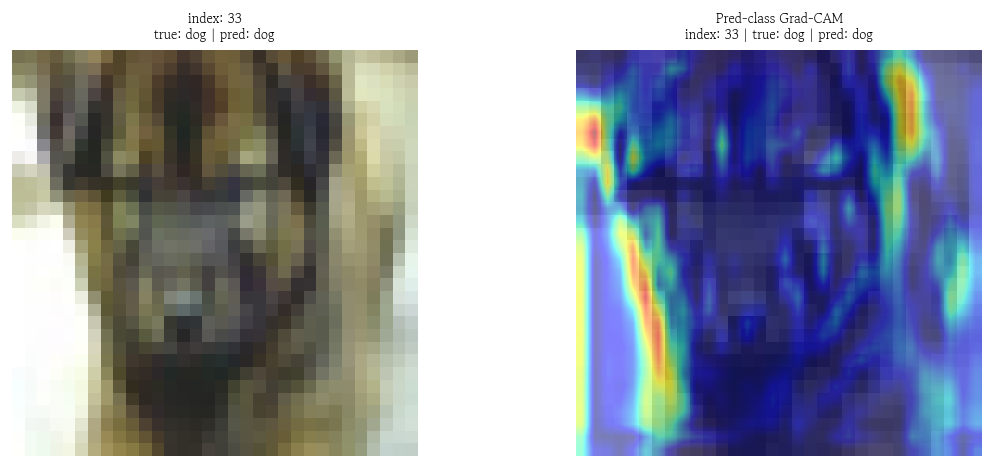

In [92]:
viewer.plot_sample(index=33, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

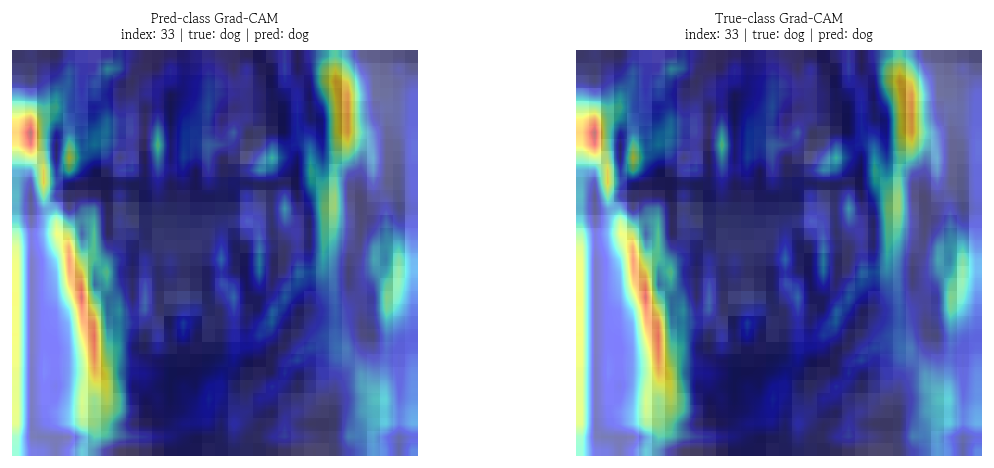

In [93]:
viewer.plot_pred_true_comparison(index=33, mean=[0.4914, 0.4822, 0.4466], std=[0.2470, 0.2435, 0.2616]);

## 훈련셋 준비

In [94]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

In [95]:
train_cifar10 = CIFAR10(root='../../data', train=True, transform=None)

In [97]:
train_cifar10.data.shape

(50000, 32, 32, 3)

In [98]:
pixels = torch.from_numpy(train_cifar10.data).float() / 255

In [99]:
cifar10_avg = pixels.mean(dim=(0, 1, 2))
cifar10_std = pixels.std(dim=(0, 1, 2))

## 데이터 증강

In [100]:
transform_train = transforms.Compose(
    transforms=[
        transforms.RandomRotation(degrees=10.0),
        transforms.RandomCrop(size=(32, 32), padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=cifar10_avg, std=cifar10_std)
    ]
)

In [101]:
train_cifar10 = CIFAR10(root='../../data', train=True, transform=transform_train)

In [102]:
set_seed()

In [103]:
train_loader = DataLoader(dataset=train_cifar10, batch_size=bs, shuffle=True)

In [104]:
model = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
    nn.BatchNorm2d(num_features=32),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(in_features=32*16*16, out_features=256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features=256, out_features=10),
).to(device)

In [105]:
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [106]:
trainer.model = model
trainer.optimizer = optimizer

In [107]:
history = trainer.fit(n_epochs=10)

[Epoch 01] Loss = 1.6522, Train_Acc = 0.5737, Test_Acc = 0.5648
[Epoch 02] Loss = 1.2100, Train_Acc = 0.6437, Test_Acc = 0.6206
[Epoch 03] Loss = 1.0499, Train_Acc = 0.6919, Test_Acc = 0.6586
[Epoch 04] Loss = 0.9602, Train_Acc = 0.7311, Test_Acc = 0.6800
[Epoch 05] Loss = 0.8867, Train_Acc = 0.7411, Test_Acc = 0.6719
[Epoch 06] Loss = 0.8417, Train_Acc = 0.7710, Test_Acc = 0.6941
[Epoch 07] Loss = 0.7873, Train_Acc = 0.7664, Test_Acc = 0.6828
[Epoch 08] Loss = 0.7400, Train_Acc = 0.8020, Test_Acc = 0.6999
[Epoch 09] Loss = 0.7023, Train_Acc = 0.8286, Test_Acc = 0.7024
[Epoch 10] Loss = 0.6690, Train_Acc = 0.8279, Test_Acc = 0.6977
Total training time: 0 min 59 sec


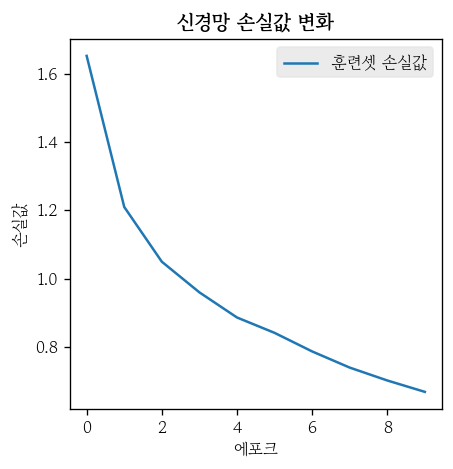

In [108]:
trainer.plot_loss()

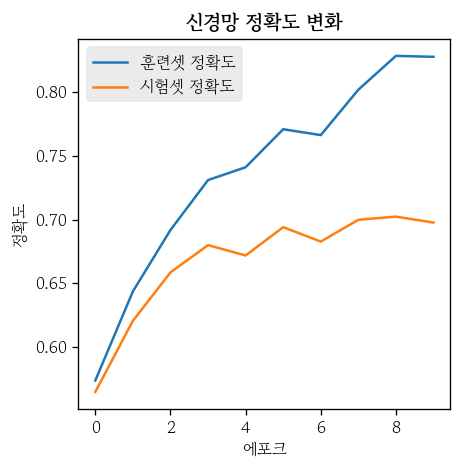

In [109]:
trainer.plot_accuracy()

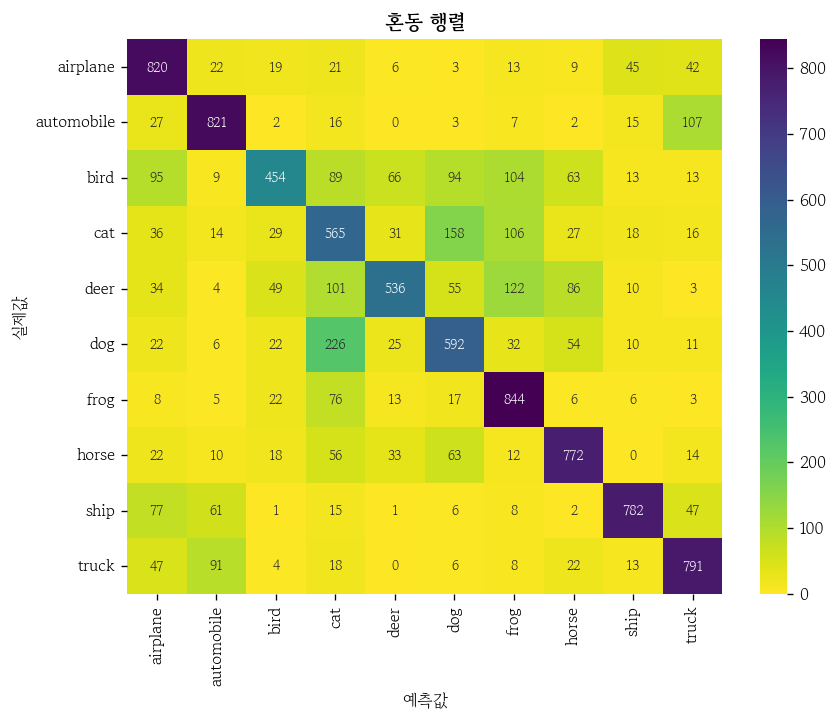

In [110]:
trainer.plot_confusion_matrix(data_loader=test_loader)

In [114]:
cifar10_avg = [round(v.item(), 4) for v in cifar10_avg]
cifar10_std = [round(v.item(), 4) for v in cifar10_std]

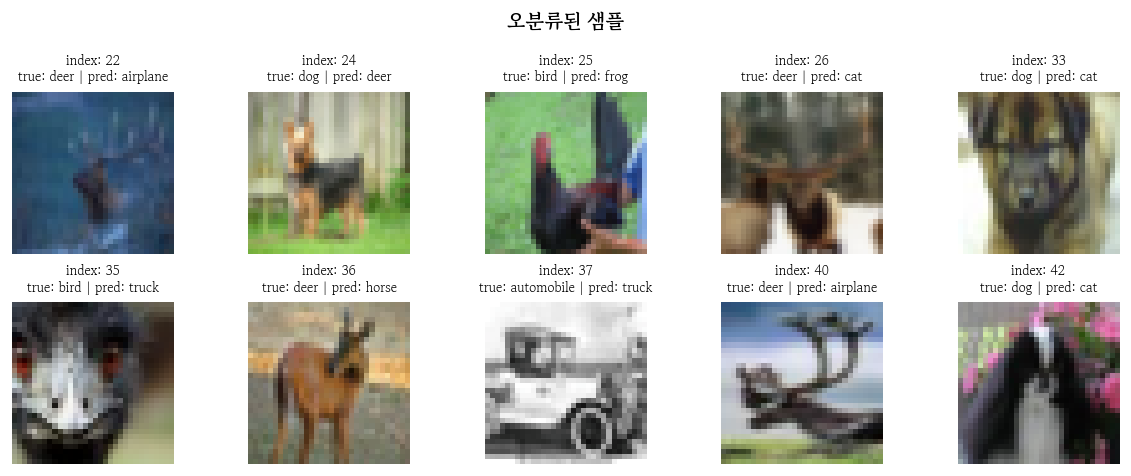

In [115]:
trainer.plot_misclassified(data_loader=test_loader, mean=cifar10_avg, std=cifar10_std)

In [123]:
y_prob, y_pred, y_true = trainer.predict_loader(test_loader)

In [124]:
mis_index = torch.where(y_true.ne(y_pred))[0]

In [125]:
model.eval()

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (7): Flatten(start_dim=1, end_dim=-1)
  (8): Linear(in_features=8192, out_features=256, bias=True)
  (9): ReLU()
  (10): Dropout(p=0.3, inplace=False)
  (11): Linear(in_features=256, out_features=10, bias=True)
)

In [126]:
target_layer = model[3]

In [127]:
viewer = GradCAMViz(model=model, target_layer=target_layer, data_loader=test_loader)

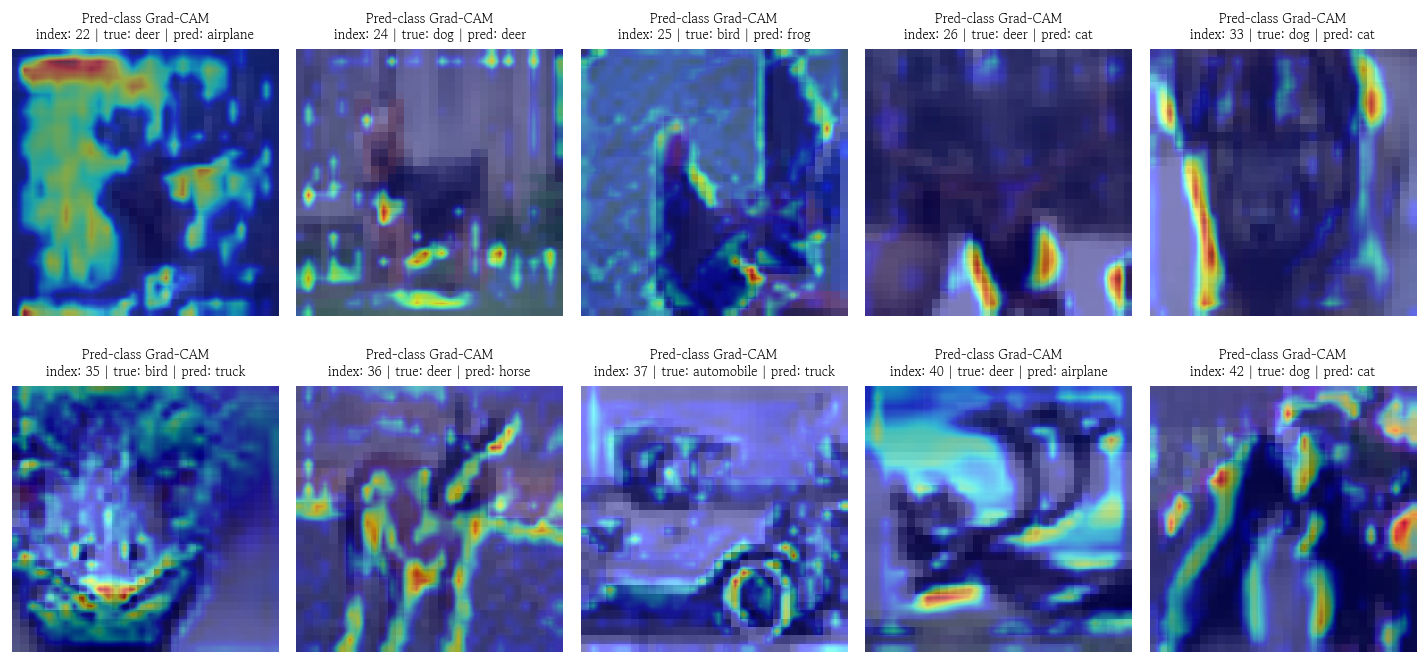

In [128]:
viewer.plot_multiple_samples(indices=mis_index[:10], ncols=5, nrows=2, mean=cifar10_avg, std=cifar10_std);

In [122]:
viewer.close()

In [129]:
index = 22

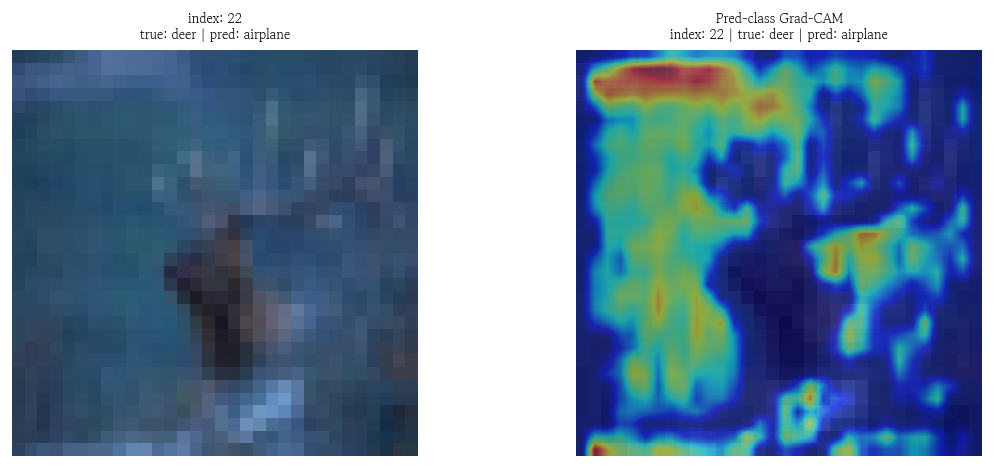

In [131]:
viewer.plot_sample(index=index, mean=cifar10_avg, std=cifar10_std);

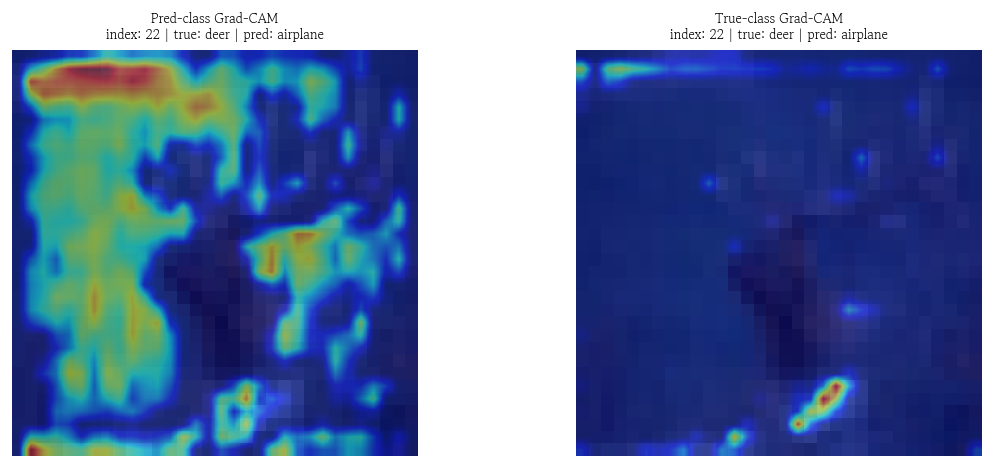

In [132]:
viewer.plot_pred_true_comparison(index=index, mean=cifar10_avg, std=cifar10_std);